# Apple Inc. Financial Analysis (1980–2026)

## 📌 Objetivo
Analizar 45+ años de datos financieros de Apple Inc. para identificar tendencias 
de revenue por producto, correlación con precio de acción y estacionalidad trimestral.

---

## 🔍 Preguntas de Negocio
1. ¿Qué línea de producto lidera el revenue de Apple en los últimos 10 años?
2. ¿Existe correlación entre el precio de cierre y el revenue trimestral?
3. ¿Qué trimestre fiscal genera históricamente más revenue?

---

## 🛠️ Stack Técnico
- **Python / pandas** — limpieza, transformación y análisis
- **matplotlib** — visualizaciones de tendencias
- **SQL** — queries de extracción y análisis agregado
- **Excel** — dashboard interactivo

---

## 📋 Flujo del Análisis
1. Carga y estructura de datos
2. Limpieza y verificación de calidad
3. Análisis descriptivo
4. Análisis de revenue por producto
5. Correlación precio vs revenue
6. Estacionalidad trimestral
7. Visualizaciones finales
8. Insights y conclusiones

# Carga y estructura de datos

In [18]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Detecta automáticamente la raíz del proyecto
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
df = pd.read_csv(os.path.join(BASE_DIR, '..', 'data', 'raw', 'aapl_master_enriched.csv'))

# Exploración inicial
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Período: {df['date'].min()} → {df['date'].max()}")
print("\n=== NULOS POR COLUMNA (solo columnas relevantes) ===")
cols_relevantes = ['date', 'close', 'volume',
                   'revenue_iphone', 'revenue_mac', 'revenue_services',
                   'revenue_wearables_other', 'revenue_ipad', 'revenue_total',
                   'fiscal_year', 'fiscal_quarter']

df_apple = df[cols_relevantes].copy()
print(df_apple.isnull().sum())
print(f"\n=== PRIMERAS 5 FILAS ===")
print(df_apple.head())

print(f"\n=== REVENUES ===")
print(df_apple.dropna(subset=['revenue_total']).shape[0])
print(df_apple['revenue_total'].dropna().head(10))

Filas: 11,370 | Columnas: 81
Período: 1980-12-12 → 2026-01-23

=== NULOS POR COLUMNA (solo columnas relevantes) ===
date                          0
close                         0
volume                        0
revenue_iphone             9360
revenue_mac                9360
revenue_services           9360
revenue_wearables_other    9360
revenue_ipad               9360
revenue_total              9360
fiscal_year                   0
fiscal_quarter                0
dtype: int64

=== PRIMERAS 5 FILAS ===
         date     close     volume  revenue_iphone  revenue_mac  \
0  1980-12-12  0.098389  469033600             NaN          NaN   
1  1980-12-15  0.093256  175884800             NaN          NaN   
2  1980-12-16  0.086412  105728000             NaN          NaN   
3  1980-12-17  0.088550   86441600             NaN          NaN   
4  1980-12-18  0.091118   73449600             NaN          NaN   

   revenue_services  revenue_wearables_other  revenue_ipad  revenue_total  \
0            

# Creacion de dataframes

In [19]:
# DataFrame 1: Precios diarios
df_precios = df_apple[['date', 'close', 'volume']].copy()
df_precios['date'] = pd.to_datetime(df_precios['date'])

# DataFrame 2: Revenue trimestral sin duplicados
df_revenue = df_apple.dropna(subset=['revenue_total'])\
                     .drop_duplicates(subset=['fiscal_year', 'fiscal_quarter'])\
                     [['fiscal_year', 'fiscal_quarter',
                       'revenue_total', 'revenue_iphone',
                       'revenue_mac', 'revenue_services',
                       'revenue_wearables_other', 'revenue_ipad']].copy()

# Convertir a millones
cols_revenue = ['revenue_total', 'revenue_iphone', 'revenue_mac',
                'revenue_services', 'revenue_wearables_other', 'revenue_ipad']
df_revenue[cols_revenue] = df_revenue[cols_revenue] / 1_000_000

print(f"✅ Precios diarios: {df_precios.shape[0]:,} filas")
print(f"✅ Trimestres únicos: {df_revenue.shape[0]}")
print(df_revenue.tail())


df_reciente = df_revenue[df_revenue['fiscal_year'] >= 2015]

resumen = df_reciente.groupby('fiscal_year')[cols_revenue].sum().round(0)
print(resumen)

✅ Precios diarios: 11,370 filas
✅ Trimestres únicos: 32
       fiscal_year fiscal_quarter  revenue_total  revenue_iphone  revenue_mac  \
10977         2024             Q4       391035.0        201183.0      29984.0   
11041         2025             Q1       416161.0        209586.0      33708.0   
11105         2025             Q2       416161.0        209586.0      33708.0   
11165         2025             Q3       416161.0        209586.0      33708.0   
11227         2025             Q4       416161.0        209586.0      33708.0   

       revenue_services  revenue_wearables_other  revenue_ipad  
10977           96169.0                  37005.0       26694.0  
11041          109158.0                  35686.0       28023.0  
11105          109158.0                  35686.0       28023.0  
11165          109158.0                  35686.0       28023.0  
11227          109158.0                  35686.0       28023.0  
             revenue_total  revenue_iphone  revenue_mac  revenue_se

# ¿Qué línea de producto lidera el revenue de Apple en los últimos 10 años?

**Hipótesis:** El iPhone representa la mayor fuente de ingresos de Apple 
en los últimos 10 años, superando significativamente a otras líneas de producto.

**Metodología:**
- Dataset: revenue trimestral 2015-2026 (`df_reciente`)
- Agrupación por año fiscal (`fiscal_year`)
- Comparativa: iPhone vs Mac

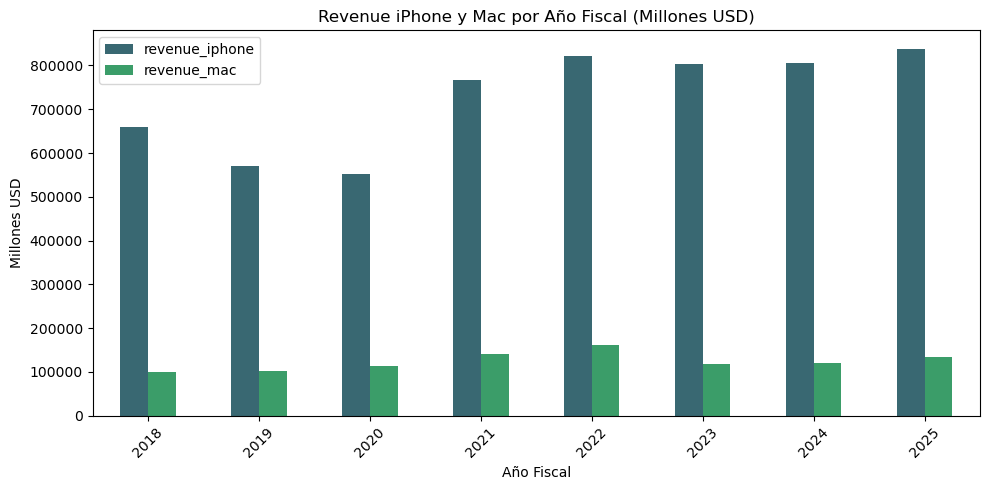

In [20]:
df_reciente.groupby('fiscal_year')[['revenue_iphone', 'revenue_mac']].sum().plot(
    kind='bar', color=['#396872', "#3b9d69"], figsize=(10,5))
plt.title('Revenue iPhone y Mac por Año Fiscal (Millones USD)')
plt.xlabel('Año Fiscal')
plt.ylabel('Millones USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 💡 Insight 1

El iPhone alcanzó su pico máximo de revenue en el año fiscal **2025**, 
consolidándose como la línea de producto más importante de Apple 
a lo largo de la última década.

El Mac, aunque consistente, representa una fracción significativamente 
menor del revenue total — confirmando la hipótesis inicial de dominancia del iPhone.